# Obsidian-git Overcommit Compress-o-matic

## Purpose

The `obsidian-git` plugin for Obsidian isn't just an excellent way to sync your vaults for free, it's also a way to visually represent the activity in your Second Brain via the commit history. However, an extremely active user will generate hundreds of commits per month, and that activity will overwhelm other activity in your GitHub (or CodeBerg) contribution graph.

The aim of this project is to find a middle ground between hiding your activity and losing the ability to track your progress and overrepresenting the contributions of your Obsidian notetaking.

## Approach

The approach is to compress the commit history by grouping commits into larger intervals, such as day-long, 4-hour-long, or hour-long intervals. This will allow users to see the overall activity trend without being overwhelmed by the sheer number of commits.

## How-To

To use this tool as-is, your obsidian-git repository will need to be configured a particular way. Either use that form or modify the code to suit your needs.

Particularly: the "default" branch of your repository will end up being the one that is compressed, but not the one where all of your devices will commit their changes to. This is critical not to get wrong, as you will end up destroying your vault and overwriting work if you do.

In my case (and what are the defaults are configured to), all devices are configured to commit to the `master` branch with their noisy commits. The script will then merge-commit without fast-forward into the `develop` branch according to the settings chosen for the tool. Finally, exclusively these merge commits will be cherry-picked into the official default `main` branch. Essentially:
- `master` is the "effective" but not "official" default branch
- `develop` is the intermediate branch between `master` and `main` **and will be deleted when changing parameters**
- `main` is the "official" default branch **and will be deleted when changing parameters**

All three branches must be present locally.

As noted above `master` will be the source where all your noisy commits come from. `develop` and `main` will be the target branches, and will be totally cleared and re-built when the parameters are changed. On the other hand, as long as the parameters are not changed, the script will merely update with changes from the last run forward.

Note: In certain edge-cases, a full reset and rerun may be desired, or even required. This can occur for a lot of reasons, usually a mistake in synchronization between devices/repos, or edge-cases in how the windows are determined.


In [89]:
import git
# Install into the *current kernel* environment
!"{sys.executable}" -m pip install -U gitpython plotly pandas nbformat
from pathlib import Path
from git import Repo
from datetime import datetime, timedelta, timezone
import pandas as pd
import plotly.express as px


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [90]:
# Settings / constants
REPO_PATH = Path(r"~/Obsidian Vault/")

WORKING_BRANCH_NAME = "master"
DEFAULT_BRANCH_NAME = "main"
INTERMEDIATE_BRANCH_NAME = "develop"
WINDOW_SIZE = 2 * 60 * 60 # 2 hours

# TODO: Find some way to reset the DEFAULT and INTERMEDIATE branches when any of the parameters change instead of always resetting.



if REPO_PATH is None:
    exit(1)

In [91]:
# Dynamic constants for this run
beginning_of_today = datetime.now(tz=datetime.now(timezone.utc).astimezone().tzinfo).replace(hour=0, minute=0, second=0, microsecond=0)
beginning_of_today

datetime.datetime(2026, 3, 8, 0, 0, tzinfo=datetime.timezone(datetime.timedelta(seconds=3600), 'CET'))

In [92]:
repo = Repo(str(REPO_PATH), search_parent_directories=True)
working_branch = repo.branches[WORKING_BRANCH_NAME]
working_head = working_branch.commit
default_branch = repo.branches[DEFAULT_BRANCH_NAME]
default_head = default_branch.commit
intermediate_branch = repo.branches[INTERMEDIATE_BRANCH_NAME]
intermediate_head = intermediate_branch.commit

working_commits = list(repo.iter_commits(working_head))
merged_commits = list(repo.iter_commits(intermediate_head))
cherry_picked_commits = list(repo.iter_commits(default_head))

In [93]:
all_new_commits = set(working_commits) - set(merged_commits) # The set of all commits in the working branch that aren't in the intermediate branch
new_commits = [commit for commit in all_new_commits if commit.committed_datetime < beginning_of_today]

if len(new_commits) == 0:
    print("No new commits from past days found")
    exit(0)

new_commits.sort(key=lambda x: x.committed_datetime, reverse=True)

# With the sorted list of commits in order, we can now bin them into windows.
# pop the next commit, keep popping until the last commit popped is beyond the window size
merge_points = []
pointer = new_commits.pop()
next_pointer = None
while len(new_commits) > 0:
    next_pointer = new_commits.pop()
    if next_pointer.committed_datetime >= pointer.committed_datetime + timedelta(seconds=WINDOW_SIZE):
        merge_points.append(pointer)
        pointer = next_pointer
merge_points.append(pointer)
pd.DataFrame([{"commit_hash": commit.hexsha, "timestamp": commit.committed_datetime} for commit in merge_points])

,commit_hash,timestamp
0,59e96d5b4a389edfe83668a33e5b17959d39b4a1,2024-03-20 00:00:37+01:00
1,96651f0422ba6279743eec3b220e6e27e195bb25,2024-03-20 23:39:27+01:00
2,f0220b2876dd3c94a6a8c4c14132fc061da022f8,2024-03-22 21:01:15+01:00
3,04e39991557bde0b9896cc329c53531eb49c4024,2024-03-22 23:28:22+01:00
4,d71e45b43772434c88065e4e64e3b9e4ff9c198e,2024-03-23 01:47:41+01:00
...,...,...
536,9a8b2ccba26f7c03b69b956535be16babd30363c,2025-10-15 10:15:25+02:00
537,ed4c5e1e4876ed6b8b2a403dd28acf16ba005f8c,2025-10-15 18:39:13+02:00
538,cad2057a6aedbda282ac7196151fe6e28c1beb82,2025-10-16 11:42:43+02:00
539,02c55b90e1c6c49eeda844c4ecf9ed6cead907c1,2025-10-16 15:15:20+02:00


In [94]:
new_merge_commits = []
for commit in merge_points:
    repo.head.reference = repo.create_head(INTERMEDIATE_BRANCH_NAME, intermediate_branch, True)
    repo.head.reset(index=True, working_tree=True)
    new_merge = repo.index.commit(
        f"Merge commit: {commit.hexsha} into {INTERMEDIATE_BRANCH_NAME}",
        [repo.head.commit, commit],
        author=commit.author,
        committer=commit.committer,
        author_date=commit.committed_datetime,
        commit_date=commit.committed_datetime
    )
    new_merge_commits.append(new_merge)

In [95]:
len(new_merge_commits)

541

In [96]:
# cherry pick the new commits from develop into main
for commit in new_merge_commits:
    repo.head.reference = repo.create_head(DEFAULT_BRANCH_NAME, default_branch, True)
    repo.head.reset(index=True, working_tree=True)

    new_cherrypick = repo.index.from_tree(repo, commit).commit(
        f"Cherry-pick commit: {commit.hexsha} into {DEFAULT_BRANCH_NAME}",
        [repo.head.commit],
        author=commit.author,
        committer=commit.committer,
        author_date=commit.committed_datetime,
        commit_date=commit.committed_datetime
    )

In [97]:
# DIVERSION! Let's plot how many commits I'll have for each window size:

all_new_commits = set(working_commits) - set(merged_commits) # The set of all commits in the working branch that aren't in the intermediate branch
new_commits = [commit for commit in all_new_commits if commit.committed_datetime < beginning_of_today]

if len(new_commits) == 0:
    print("No new commits from past days found")
    exit(0)

new_commits.sort(key=lambda x: x.committed_datetime, reverse=True)
backup_new_commits = new_commits.copy()


expected_merge_counts = []
for i in range(60, 24 * 60 * 60, 60):
    new_commits = backup_new_commits.copy()

    # With the sorted list of commits in order, we can now bin them into windows.
    # pop the next commit, keep popping until the last commit popped is beyond the window size
    merge_points = []
    pointer = new_commits.pop()
    next_pointer = None
    while len(new_commits) > 0:
        next_pointer = new_commits.pop()
        if next_pointer.committed_datetime >= pointer.committed_datetime + timedelta(seconds=i):
            merge_points.append(pointer)
            pointer = next_pointer
    merge_points.append(pointer)

    expected_merge_counts.append(len(merge_points))

expected_merge_counts

<Axes: title={'center': 'Expected Number of Merges for Each Window Size'}, xlabel='Window Size (minutes)', ylabel='Number of Merges'>

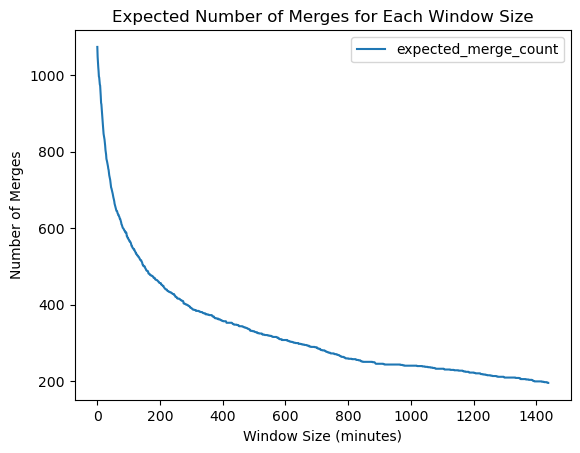

In [98]:
pd.DataFrame({"expected_merge_count": expected_merge_counts}).plot(xlabel="Window Size (minutes)", ylabel="Number of Merges", title="Expected Number of Merges for Each Window Size")

### Everything below is old and bad

In [99]:
all_new_commits = set(working_commits) - set(merged_commits) # The set of all commits in the working branch that aren't in the intermediate branch
new_commits = [{'commit': commit, 'commit_hash': commit.hexsha, 'timestamp': commit.committed_datetime, 'commit_message': commit.message} for commit in all_new_commits if commit.committed_datetime < beginning_of_today]
new_commits.sort(key=lambda x: x['timestamp'], reverse=False)
pd.DataFrame(new_commits, columns=["commit_hash", "commit_message", "timestamp"])

,commit_hash,commit_message,timestamp
0,59e96d5b4a389edfe83668a33e5b17959d39b4a1,vault backup: 2024-03-20 00:00:37\n,2024-03-20 00:00:37+01:00
1,96651f0422ba6279743eec3b220e6e27e195bb25,vault backup: 2024-03-20 23:39:27\n,2024-03-20 23:39:27+01:00
2,f0220b2876dd3c94a6a8c4c14132fc061da022f8,vault backup: 2024-03-22 21:01:15\n,2024-03-22 21:01:15+01:00
3,0618013345e67632a6f87d41c0ff32492e932b3f,vault backup: 2024-03-22 21:11:42\n,2024-03-22 21:11:42+01:00
4,4d16cd7b55c9cada4e284e74ad1b0f77c654642d,vault backup: 2024-03-22 22:35:50\n,2024-03-22 22:35:50+01:00
...,...,...,...
1122,2e1b0e04e4c8d79b5f67c2258ed7a29a00589a37,vault backup: 2025-10-15 19:32:49\n\nAffected ...,2025-10-15 19:32:52+02:00
1123,cad2057a6aedbda282ac7196151fe6e28c1beb82,vault backup: 2025-10-16 11:42:41\n\nAffected ...,2025-10-16 11:42:43+02:00
1124,f8e202b0440583850796c10abf2803a3e3616f1b,vault backup: 2025-10-16 11:57:44\n\nAffected ...,2025-10-16 11:57:44+02:00
1125,02c55b90e1c6c49eeda844c4ecf9ed6cead907c1,vault backup: 2025-10-16 15:15:20\n\nAffected ...,2025-10-16 15:15:20+02:00


In [100]:
pd.DataFrame([
    {"title": "Commits in WORKING that aren't in INTERMEDIATE", "commits": len(set(working_commits) - set(merged_commits))},
    {"title": "Commits in INTERMEDIATE that aren't in WORKING", "commits": len(set(merged_commits) - set(working_commits))},
    {"title": "Commits in DEFAULT that aren't in INTERMEDIATE", "commits": len(set(cherry_picked_commits) - set(merged_commits))},
])

,title,commits
0,Commits in WORKING that aren't in INTERMEDIATE,1127
1,Commits in INTERMEDIATE that aren't in WORKING,0
2,Commits in DEFAULT that aren't in INTERMEDIATE,0
